<a href="https://colab.research.google.com/github/007arjungangwar/Foundations-of-Data-Engineering-Sec1/blob/main/Data_Augmentation_single_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Array
(Height, Width, Channels)

<img src="https://editor.analyticsvidhya.com/uploads/488590%20CI5wgSszZnpHu5Ip.png" alt="imgpixels" style="height: 200px; width:600px;"/>

In [1]:
import matplotlib.pyplot as plt

In [2]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
img = image.load_img('/content/cat images.jpg', target_size=(200, 200))

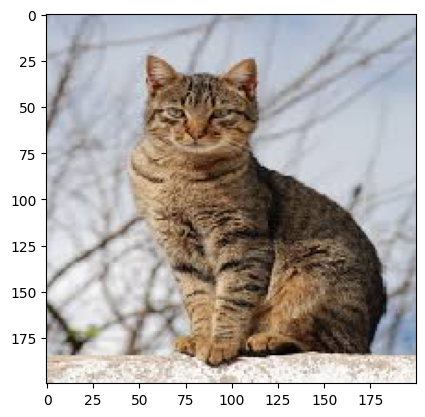

In [6]:
plt.imshow(img)

In [7]:
type(img)

PIL.Image.Image

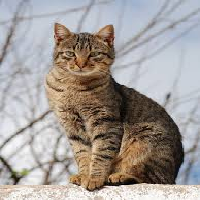

In [8]:
img

In [10]:
img = image.img_to_array(img)

In [11]:
type(img)

numpy.ndarray

### **Image as a number**

In [12]:
img

array([[[153., 161., 180.],
        [161., 169., 188.],
        [170., 178., 197.],
        ...,
        [182., 193., 211.],
        [180., 191., 209.],
        [179., 192., 208.]],

       [[154., 162., 181.],
        [162., 170., 189.],
        [171., 179., 198.],
        ...,
        [182., 193., 211.],
        [180., 192., 208.],
        [179., 192., 208.]],

       [[160., 168., 187.],
        [167., 175., 194.],
        [176., 184., 203.],
        ...,
        [184., 192., 211.],
        [180., 192., 208.],
        [179., 192., 208.]],

       ...,

       [[193., 177., 164.],
        [238., 222., 209.],
        [228., 214., 203.],
        ...,
        [234., 229., 225.],
        [241., 240., 236.],
        [240., 241., 236.]],

       [[198., 180., 168.],
        [220., 204., 191.],
        [208., 191., 183.],
        ...,
        [243., 239., 236.],
        [248., 247., 245.],
        [247., 247., 245.]],

       [[196., 178., 166.],
        [211., 195., 182.],
        [192., 1

In [13]:
img.shape

(200, 200, 3)

In [14]:
import pandas as pd

**Distribution of Pixel Values**

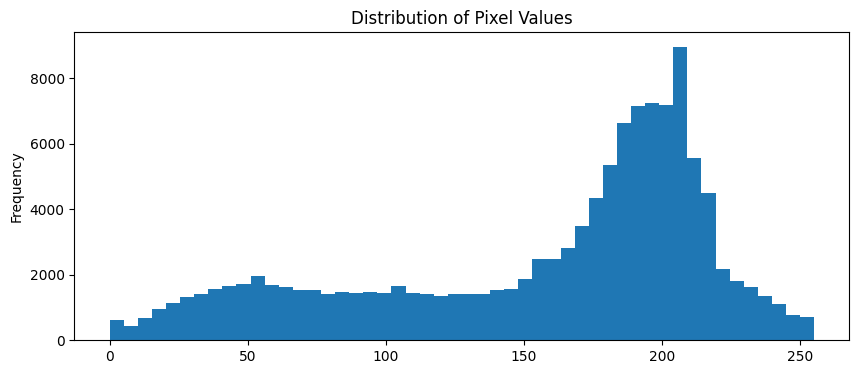

In [18]:
pd.Series(img.flatten()).plot(kind='hist',bins=50,title='Distribution of Pixel Values',figsize=(10,4))
plt.show()

# Image Channels

<img src="https://upload.wikimedia.org/wikipedia/commons/2/28/RGB_illumination.jpg" alt="Result3" style="width:300px;"/>

## RGB Channels

An RGB image has three channels: red, green, and blue. RGB channels roughly follow the color receptors in the human eye, and are used in computer displays and image scanners.

Source: [Wikipedia](https://en.wikipedia.org/wiki/Channel_(digital_image)#:~:text=RGB%20images,-An%20RGB%20image&text=If%20the%20RGB%20image%20is,intensities%20between%200%20and%20255.)

<img src="https://i.imgur.com/g0R7AD3.png" alt="Result3" style="height: 300px; width:300px;"/>


# **Display RGB Channels of our image**

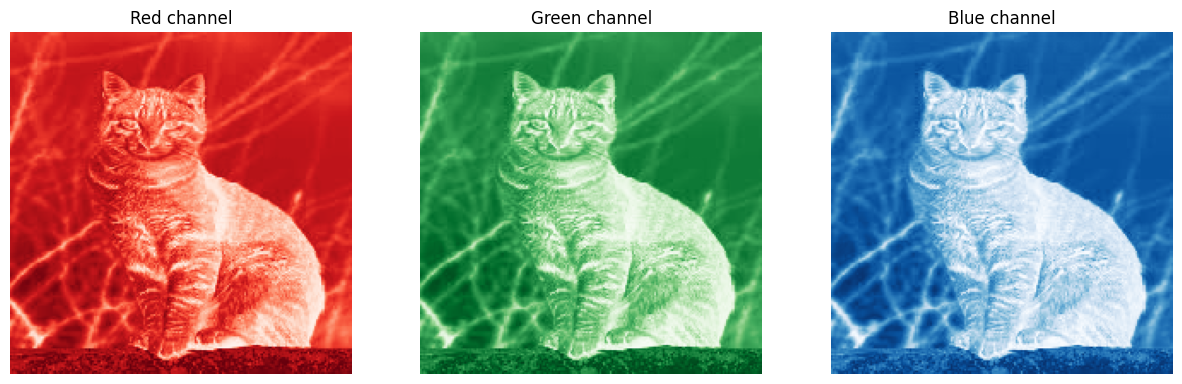

In [19]:
# Display RGB Channels of our image
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img[:,:,0], cmap='Reds')
axs[1].imshow(img[:,:,1], cmap='Greens')
axs[2].imshow(img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

In [20]:
import cv2

# **Display gray Channels of our image**

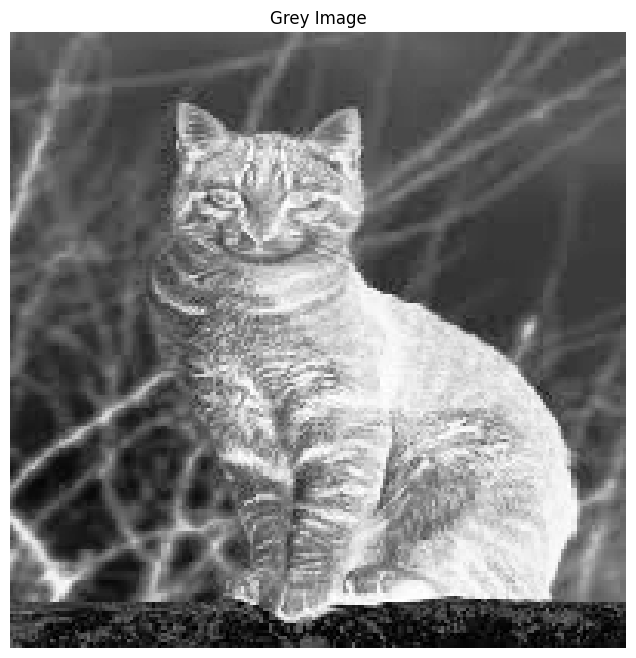

In [21]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_gray, cmap='Greys')
ax.axis('off')
ax.set_title('Grey Image')
plt.show()

# **Starting Data Augmentation for single Image**

first create object of ImageDataGenerator class

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    #vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    #fill_mode='constant' #reflect, wrap, nearest
)

**fix the size required for preprocessing of any ML/DL Model**

In [ ]:
input_batch = img.reshape(1, 200, 200, 3)

### **Create the images**

In [ ]:
# Cell 3
i = 0

for output in datagen.flow(input_batch, batch_size=1, save_to_dir='/content/new cat'):
    i = i + 1
    if i == 10:
        break